In [1]:
import sys, os
from pathlib import Path

# Colab-specific setup
if 'google.colab' in sys.modules:
    if not os.path.exists("ioer-conference-2026-haclathon"):
        !git clone -q https://github.com/ioer-dresden/ioer-conference-2026-haclathon.git
    %cd -q ioer-conference-2026-haclathon/notebooks

# Universal package install
pyexec = sys.executable
!../py/modules/pkginstall.sh "{pyexec}" geopandas matplotlib datashader pygal dotenv pygeohash libpysal contextily duckdb mapclassify adjustText cartopy geoviews dask

geopandas already installed (version 1.1.3).
matplotlib already installed (version 3.10.9).
datashader already installed (version 0.19.1).
pygal already installed (version 3.1.3).
dotenv already installed (version 1.2.2).
pygeohash already installed (version 3.3.1).
libpysal already installed (version 4.14.1).
contextily already installed (version 1.7.0).
duckdb already installed (version 1.5.5).
mapclassify already installed (version 2.10.0).
adjustText already installed (version 1.4.0).
cartopy already installed (version 0.25.0).
geoviews already installed (version 1.15.1).
dask already installed (version 2026.8.0).


# Digital Landscape Traces: Mapping Visitor Frequentation in Germany

* **Authors**: Alexander Dunkel (IOER) & Dominik Weckmüller (TU Dresden)
* **Topics**: Transformative Governance, Urban & Regional Planning, Open Data Re-use
*  **Badges**: ![Interactive](https://img.shields.io/badge/Type-Interactive_Code-blue?style=flat-square) ![Colab](https://img.shields.io/badge/Colab-Tested-yellow?style=flat-square&logo=googlecolab&logoColor=white) ![Jupyter](https://img.shields.io/badge/Jupyter4NFDI-Ready-orange?style=flat-square&logo=jupyter)

```{admonition} Summary
:class: hint

This chapter explores how openly published replication packages can bridge the gap between academic research and public data journalism. We use a dataset of 66 million social media posts ({cite:alp}`dunkel_replication_2025`) that was recently published as a 'Replication Package' for a peer-reviewed publication ({cite:alp}`Dunkel2025DigitaleSpuren`). We will first reproduce a published scientific map, and repurpose the data to explore local vs. tourist hotspots for a regional planning review.
```

```{warning}
This chapter is a work in progress.
```

---

## 1. Introduction

In recent years, the scientific community has faced a growing challenge of decreasing trust from the public [Ref!]. One of the root causes is the the reproducibility crisis. This refers to the inability to transparently verify published research results. When complex spatial analyses remain locked inside proprietary software or hidden on local hard drives, the resulting publications, maps and statistics become black boxes that invite proclamation of data fabrication.

By embracing the FAIR principles (Findable, Accessible, Interoperable, Reusable), we can counter this trend. In this notebook, we document our analysis, argumentation, and interpretation fully and transparently. Every map and chart you see here can be reproduced by simply clicking the *Launch in Jupyter4NFDI* or *Launch in Colab* button at the top of this page. While preparing such computational environments requires significant effort, it is a necessary investment for the sake of credibility in modern science.

To illustrate this, we will use a dataset based on millions of georeferenced social media posts {cite:p}`dunkel_replication_2025`. Because people increasingly document their lives online, these digital traces provide a high-resolution "digital echo" of public attention. They allow us to understand how humans perceive neighborhoods, which natural habitats face extreme tourist pressure, and where locals seek everyday recreation.

By analyzing such spatial activity patterns over a long time horizon (2007–2022), planners can identify:
* **Over-tourism hotspots** in sensitive natural habitats (e.g., National Parks) [1, 2].
* **Local recreational corridors** in suburban and rural green spaces [1, 2].
* **Spatial mismatches** between visitor demand and infrastructure capacity [1, 2].

## Replication Test

The fundamental purpose of a "Replication Package" is to allow any researcher to recreate the findings of a published paper. That a dataset might be useful beyond its initial context is an excellent ancillary benefit, but it is not guaranteed. 

Therefore, let us briefly demonstrate how easily we can reproduce the primary visual artifact from the original publication *Digitale Spuren in der Landschaft* {cite:p}`Dunkel2025DigitaleSpuren`. We will load the dataset `de_classified_points.parquet` directly from the ioerDATA repository. Using the `datashader` library, we render all 66 million points, coloring them by their majority classification: locals, tourists, or unclassified users.

```{admonition} Privacy & Ethics First
:class: note
All point coordinates are snapped to a Geohash-7 grid (~153m x 153m), direct user identifiers and timestamps are removed, and platform sources are obfuscated {cite:p}`dunkel_replication_2025`. This guarantees computational reproducibility while protecting individual privacy {cite:p}`dunkel_replication_2025`. It also _limits_ reuse, to a certain degree. This is a common trade-off in geospatial data science that researchers must navigate. It requires to carefully weight FAIR principles and privacy rights.
```

### Prepare analysis

For easier development in Jupyter, we activate the autoreload of changed Python files. We also set up our local `modules` path and output directory.

In [32]:
import pandas as pd
import geopandas as gp
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import duckdb
from datashader.utils import lnglat_to_meters

%load_ext autoreload
%autoreload 2

base_path = Path.cwd().parent
module_path = str(base_path / "py")
if module_path not in sys.path:
    sys.path.append(module_path)
from modules import tools

OUTPUT = base_path / "out"
OUTPUT.mkdir(exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Preview dataset

We use DuckDB to query the Parquet files directly. This avoids loading all 66 million points into memory. The following code:

- Downloads the replication package if it doesn't exist locally.
- Connects DuckDB to the Parquet directory.
- Computes the national ratio of locals, tourists, and unclassified users.

In [33]:
%%time
parquet_dir = OUTPUT / "de_classified_points.parquet"
zip_url = "https://datashare.tu-dresden.de/s/XeBH775Pa8L5CiG/download"

if not parquet_dir.exists():
    tools.get_zip_extract(
        uri=zip_url,
        filename="de_classified_points_2007-2022.parquet.zip",
        output_path=OUTPUT
    )

con = duckdb.connect()

query_totals = f"""
    SELECT 
        classification,
        COUNT(*) AS post_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM '{parquet_dir}/*.parquet'
    GROUP BY classification
    ORDER BY post_count DESC
"""

df_totals = con.execute(query_totals).df()
print("National Dataset Overview (2007–2022)")
display(df_totals)

National Dataset Overview (2007–2022)


,classification,post_count,percentage
0,Tourist,29194828,43.81
1,Unclassified,21667289,32.52
2,Local,15770000,23.67


CPU times: user 500 ms, sys: 27.8 ms, total: 528 ms
Wall time: 106 ms


Pretty fast! Thanks to the [Parquet](https://parquet.apache.org/) format.

---

### User Challenge: Explore Your Region of Interest

:::{tip}
**Try it yourself!** Change the bounding box coordinates below to inspect visitor composition in your own region or municipality.
:::

* `MY_REGION_NAME`: The title for your output.
* `MY_BBOX_WGS84`: The `(min_lng, max_lng, min_lat, max_lat)` coordinates. Use [bboxfinder.com](https://bboxfinder.com/) (e.g.) to find decimal degree coordinates for your chosen area.

The code automatically projects these coordinates to Web Mercator (`EPSG:3857`) to match the dataset projection.

In [34]:
from datashader.utils import lnglat_to_meters

MY_REGION_NAME = "Dresden & Surroundings"
MY_BBOX_WGS84 = (13.60, 13.90, 50.98, 51.12)  # (min_lng, max_lng, min_lat, max_lat)

# Convert bounding box to Web Mercator meters
xs, ys = lnglat_to_meters(
    [MY_REGION_NAME_BBOX := MY_BBOX_WGS84][0][:2], 
    [MY_BBOX_WGS84[2], MY_BBOX_WGS84[3]]
)

query_custom = f"""
    SELECT 
        classification,
        COUNT(*) AS post_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS percentage
    FROM '{parquet_dir}/*.parquet'
    WHERE x BETWEEN {xs[0]} AND {xs[1]}
      AND y BETWEEN {ys[0]} AND {ys[1]}
    GROUP BY classification
    ORDER BY post_count DESC
"""

df_custom = con.execute(query_custom).df()

print(f"Analysis for: {MY_REGION_NAME}")
display(df_custom)

Analysis for: Dresden & Surroundings


,classification,post_count,percentage
0,Tourist,643404,46.9
1,Unclassified,512011,37.3
2,Local,216851,15.8


<!-- #region slideshow={"slide_type": ""} editable=true -->
### Reproduce original Visualizations

First, we need some geographic context. We copy the exact code from [the original publication](https://code.ad.ioer.info/digital_traces_map/html/03_visualization.html), which *documents* the exact source of base data used. Documentation and analysis go hand in hand here. We fetch the NUTS borders and filter for Germany.

<!-- #endregion -->

In [35]:
NUTS_GPKG_FILE = "NUTS_RG_01M_2024_4326.gpkg"
if not Path(OUTPUT / NUTS_GPKG_FILE).exists():
    tools.get_stream_file(
        f"https://gisco-services.ec.europa.eu/distribution/v2/nuts/gpkg/{NUTS_GPKG_FILE}", OUTPUT / NUTS_GPKG_FILE)

nuts = gp.read_file(OUTPUT / NUTS_GPKG_FILE)
nuts1_de = nuts[nuts['LEVL_CODE'] == 0]

In [28]:
from modules import digitaltraces

regions_to_plot = {
    "Dresden & Sächsische Schweiz": ((13.41, 14.70), (50.74, 51.19)),
    "Baltic Coast (Rügen/Usedom)":  ((13.00, 14.56), (54.00, 54.74)),
    "Leipzig Urban Core":           ((12.20, 12.55), (51.26, 51.37))
}

<!-- #region editable=true slideshow={"slide_type": ""} -->
Load the custom visualization module (which includes the complex Datashader code from the original publication) and define our bounding boxes.

<!-- #endregion -->

### 2.1 Regional Examples

Let's render two major tourist and recreational regions. We pull only the necessary data subset from the Parquet file to keep memory usage low, passing it to our custom `digitaltraces` module.
* `bounds`: The spatial extent of the region.
* `border`: The geographic boundaries for context.

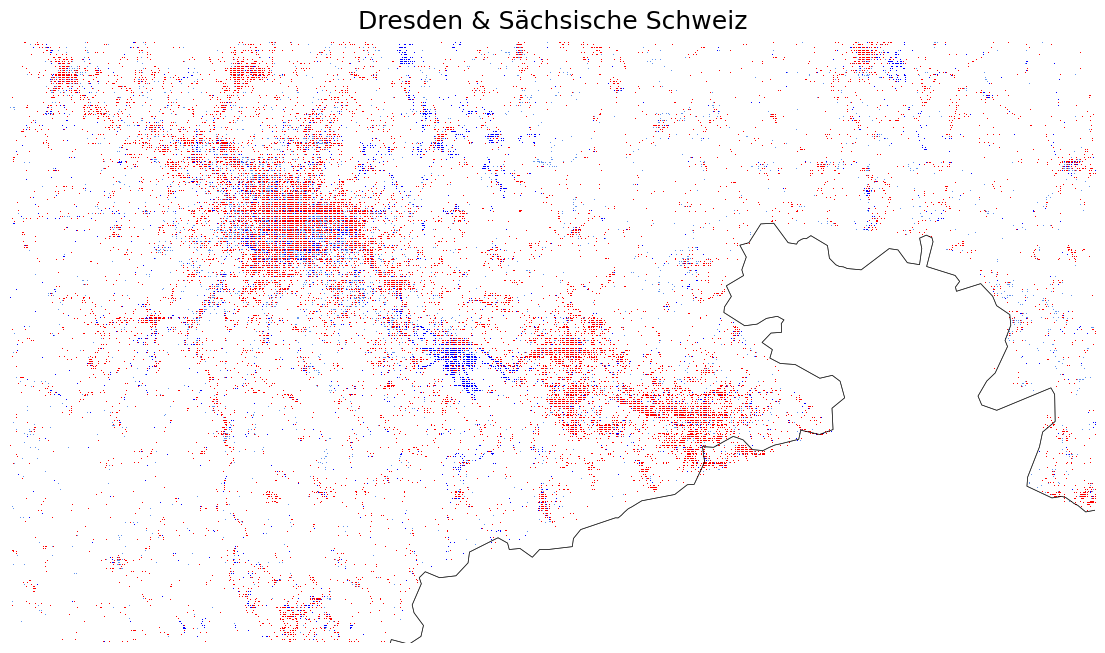

In [36]:
from modules import digitaltraces

regions_to_plot = {
    "Dresden & Sächsische Schweiz": ((13.41, 14.70), (50.74, 51.19)),
    "Baltic Coast (Rügen/Usedom)":  ((13.00, 14.56), (54.00, 54.74)),
    "Leipzig Urban Core":           ((12.20, 12.55), (51.26, 51.37))
}

name = "Dresden & Sächsische Schweiz"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

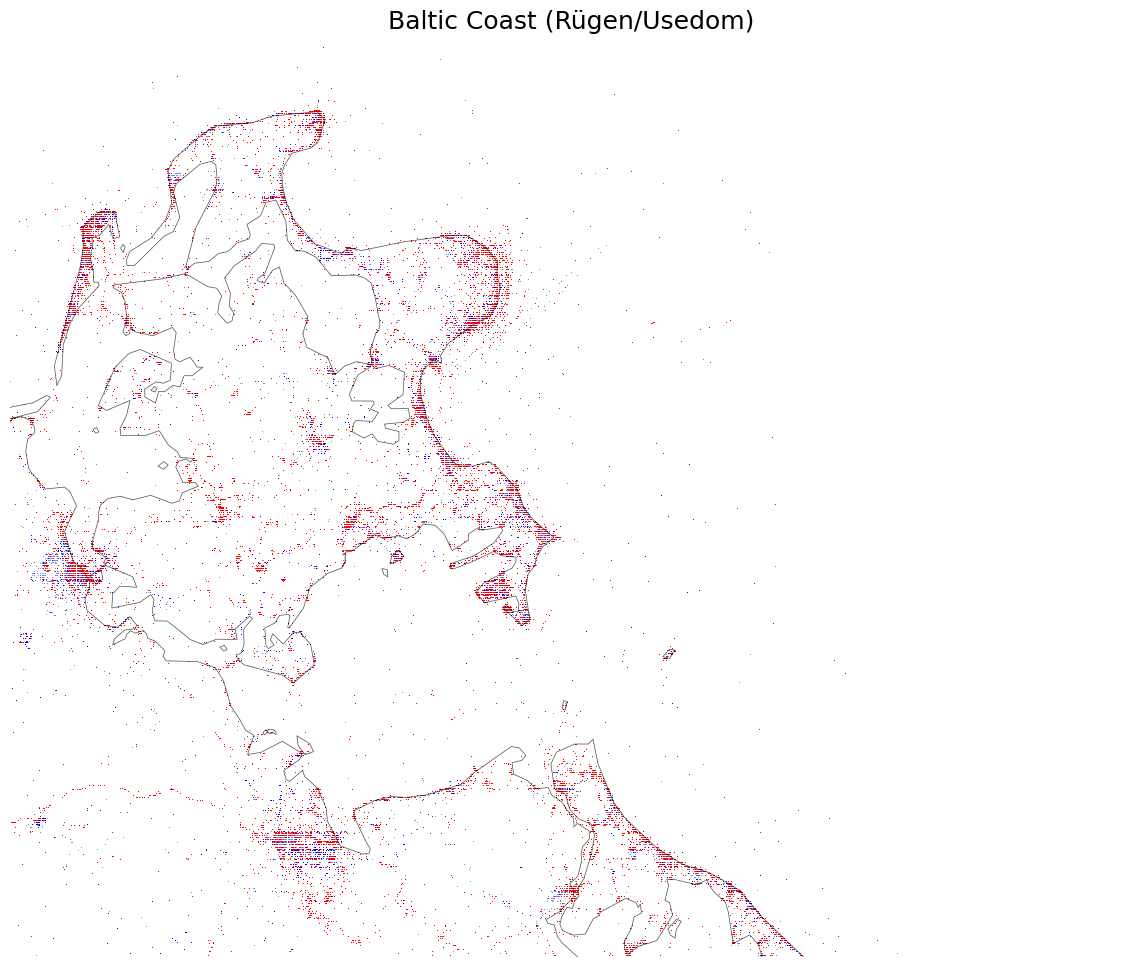

In [37]:
name = "Baltic Coast (Rügen/Usedom)"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

By maintaining a versioned environment, we can guarantee that this output matches the original publication pixel-by-pixel. The cartographic process becomes transparent. Even though it still is and remains complex: see the documentation for the initial processing of the data [here](https://code.ad.ioer.info/digital_traces_map/).

### Limits of Replication

If you look at the maps above, you will notice the fine, dotted, grid-like pattern. This is not a rendering artifact! It is the direct consequence of the **privacy-preserving Geohash-7 snapping** that was applied to the published replication dataset {cite:p}`dunkel_replication_2025`.

Because lat-lng coordinates can be highly specific, almost to the degree of Unique IDs: To prevent the re-identification of individuals, every social media post was snapped to the center of a 153x153 meter grid cell *before* publication. At the national scale, these cells overlap enough to look like smooth density clouds. But when zooming into a region, most grid cells contain only a single, isolated data point. 

When rendered with standard browser or plot anti-aliasing, these isolated 1-pixel dots blur into the white background and disappear entirely. To make them visible here, our `digitaltraces.py` module disables image smoothing (`interpolation='nearest'`) and dynamically locks the figure size to the canvas aspect ratio.

But what happens if a local planner wants to analyze a specific urban core. For example, for Leipzig? Expand the code cell below to see what happens when we over-zoom into snapped data.

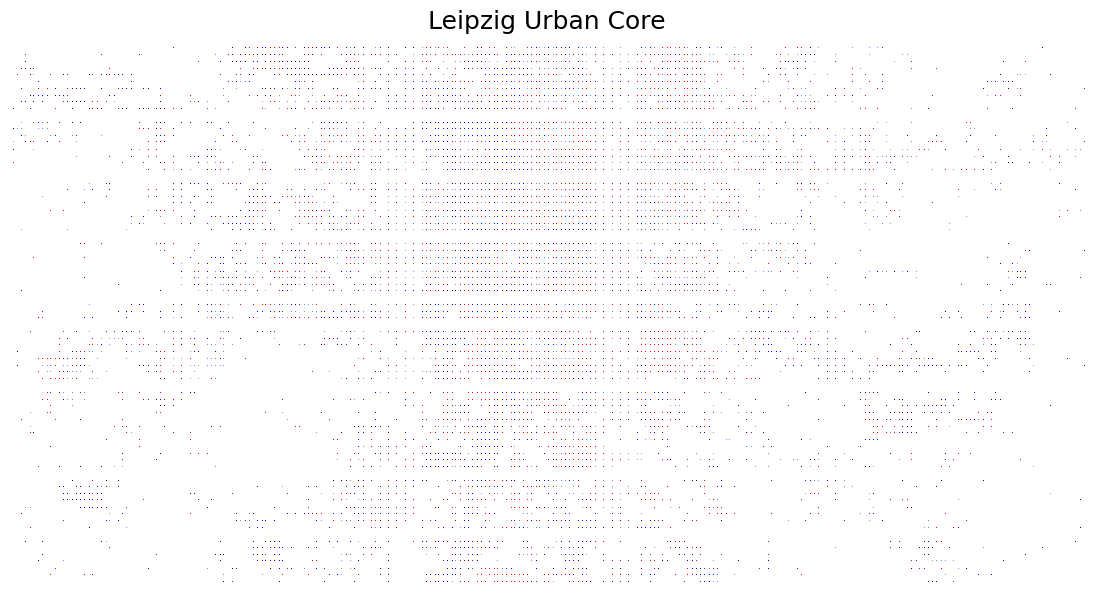

In [42]:
name = "Leipzig Urban Core"
bounds = regions_to_plot[name]

df_subset = digitaltraces.query_region(con, parquet_dir, bounds)
fig = digitaltraces.render_datashader_map(df=df_subset, bounds=bounds, border=nuts1_de, title=name)
plt.show()

At this zoom level, the data transforms into an illegible matrix. We can no longer distinguish meaningful hotspots from sparse outliers. Even a background map would be of not much help here.

This is a common trade-off in geospatial data science. Strict privacy measures limit the usefulness of raw visualizations at local scales. To extract meaningful insights for regional planning, we cannot rely on point-density alone. We must transition to advanced spatial statistics.

## 3. Beyond Replication

Once a dataset is published openly, it often sparks interest outside the academic sphere. Recently, a journalist from a national news network approached us. She was writing a story about over-tourism and wanted to report on the most popular tourist destinations in her federal state, contrasting them with the "hidden gems" preferred by the local population. 

While she found our published dataset on the ioerDATA repository, she faced a formidable technical hurdle. Analyzing a dataset of 66 million points is not feasible in standard spreadsheet software, and finding localized, statistically significant hotspots requires specific spatial methodologies. 

Her request perfectly highlights the secondary goal of open science: data re-usability. To help her tell her story, we need to move beyond rendering static national maps. We need to filter the data for specific regions, aggregate the points, and identify statistically significant clusters of activity.

### Extracting Hotspots

To find areas with unusually high visitor frequentation, we cannot simply rely on raw point density. A highly populated city center will naturally have more social media posts than a remote forest. Instead, we use a spatial statistic called the **Getis-Ord Gi\*** (pronounced G-i-star). 

This method identifies statistically significant spatial clusters of high values (hotspots) and low values (cold spots). For our journalist's story, we will focus on two contrasting areas:
1. **Sächsische Schweiz**: A renowned National Park known for international tourism.
2. **Leipzig**: A rapidly growing, vibrant urban center.

The core metric classifies social media users based on their global activity history {cite:p}`Dunkel2025DigitaleSpuren`:
* <span style="color:blue">**Local**</span>: Inferred home location is within Germany [1, 2].
* <span style="color:red">**Tourist**</span>: Inferred home location is outside Germany [1, 2].
* <span style="color:cornflowerblue">**Unclassified**</span>: Insufficient global activity to infer home location [1, 2].

In the code block below, we aggregate our point data into a spatial grid and utilize the `libpysal` library to calculate the spatial weights and the local G* statistic.

In [4]:
# PLACEHOLDER: 
# 1. DuckDB query to filter Sächsische Schweiz & Leipzig.
# 2. Aggregate points into a grid (e.g., using Datashader or Geopandas hex bins).
# 3. Apply libpysal.weights.DistanceBand and esda.G_Local (adapted from 01_mapnik-tagmaps.md).
# 4. Classify the Gi* Z-scores into hot/cold spot categories.

### Results

With our hotspots identified, we can now map these specific regions. We plot the calculated clusters over a subtle background map provided by `contextily`. 


In [2]:
# PLACEHOLDER: 
# 1. Use GeoPandas and Matplotlib to plot the Hot/Cold spots for the two regions.
# 2. Add contextily basemaps for orientation.

To provide concrete numbers for the news report, we can extract the exact ratio of locals to tourists within these newly identified hotspots. We aggregate the classifications for the top Points of Interest (POIs) and visualize them using a ranked bar chart.

In [3]:
# PLACEHOLDER: 
# 1. DuckDB query to get Local/Tourist counts within the top Gi* cluster geometries.
# 2. Render a clean, interactive SVG Pygal chart showing the distribution.

*(Text placeholder interpreting the results*)

## Conclusion

By starting with a massive, raw dataset, we were able to quickly reproduce a complex national map, verifying the original scientific claims. But more importantly, we adapted the workflow to solve a real-world problem for a journalist, transforming abstract spatial coordinates into a tangible story about human behavior.

None of this would be possible without robust research data management. Infrastructures like the IOER-FDZ and the FAIR principles they champion ensure that data is not merely archived, but kept alive. When we combine open data with cloud-based computational environments, we empower planners, journalists, and citizens to collaboratively shape the transformative governance of our cities and landscapes.

```{admonition} Methodological & Technical Architecture 
:class: dropdown, info

How was this built?

1. **Classification Pipeline**: Built using `dask` and `datashader` inside **Carto-Lab Docker** v1.1.0 {cite:p}`dunkel_replication_2025`.
2. **Privacy Measures**: Geohash-7 spatial snapping prevents 1:1 reverse matching with public online posts {cite:p}`dunkel_replication_2025`.
3. **Reproducibility**: Run directly in [Jupyter4NFDI](https://base4nfdi.de/projects/jupyter4nfdi) or Google Colab [8].
```

## References

```{bibliography}
:style: unsrt
:filter: docname in docnames
```